# Gated Recurrent Unit (GRU)

GRU is a simplified version of LSTM.

It uses fewer gates.

Therefore,

- Faster training
- Less memory
- Similar performance

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

#Load Dataset

In [2]:
vocab_size = 10000

(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Only the 10,000 most frequent words are used.

"I loved this movie"

↓

[15, 23, 128, 56]

Each number represents a word.

#Pad Sequences

In [3]:
max_length=200

X_train=pad_sequences(X_train,maxlen=max_length,padding='post')
X_test=pad_sequences(X_test,maxlen=max_length,padding='post')

#Build GRU Model

In [4]:
model=Sequential()

model.add(
    Embedding(vocab_size,
              32,
              input_length=max_length)
)

model.add(GRU(32))

model.add(Dense(1,
                activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


GRU is a simplified LSTM.

Instead of :

Forget Gate

Input Gate

Output Gate

GRU has only :

Update Gate

Reset Gate

This makes it :

simpler
faster
fewer parameters

##GRU Combines

Hidden State + Cell State -> One Memory

So it is computationally cheaper.

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#Compile

In [6]:
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

#Train

In [7]:
history=model.fit(
X_train,
y_train,
epochs=5,
batch_size=64,
validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 135ms/step - accuracy: 0.5768 - loss: 0.6696 - val_accuracy: 0.6548 - val_loss: 0.6198
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.6481 - loss: 0.6159 - val_accuracy: 0.6150 - val_loss: 0.6375
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 124ms/step - accuracy: 0.6895 - loss: 0.5754 - val_accuracy: 0.7108 - val_loss: 0.5803
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.6729 - loss: 0.6158 - val_accuracy: 0.6004 - val_loss: 0.6442
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 128ms/step - accuracy: 0.6651 - loss: 0.6072 - val_accuracy: 0.6668 - val_loss: 0.6227


#Evaluate

In [8]:
loss,accuracy=model.evaluate(X_test,y_test)

print("Accuracy:",accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.6684 - loss: 0.6219
Accuracy: 0.6684399843215942


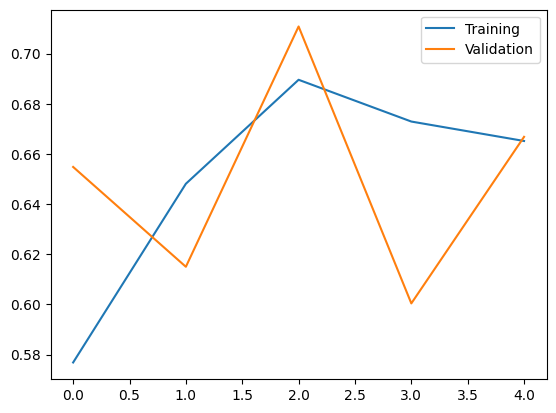

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(["Training","Validation"])
plt.show()

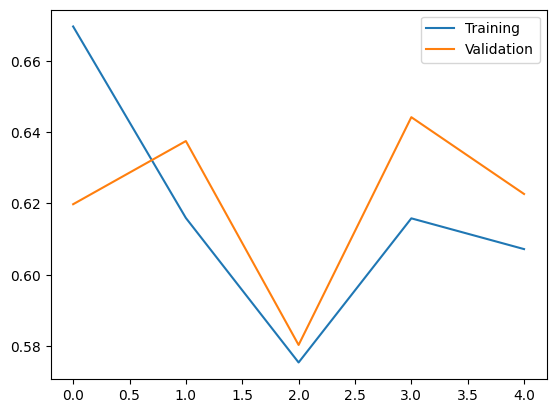

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(["Training","Validation"])
plt.show()

#Prediction

In [12]:
prediction=model.predict(X_test[:10])

for i,p in enumerate(prediction):

    print("Review",i+1)

    if p>0.5:
        print("Positive")
    else:
        print("Negative")

    print("Actual:",y_test[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
Review 1
Positive
Actual: 0
Review 2
Positive
Actual: 1
Review 3
Negative
Actual: 1
Review 4
Positive
Actual: 0
Review 5
Positive
Actual: 1
Review 6
Positive
Actual: 1
Review 7
Negative
Actual: 1
Review 8
Positive
Actual: 0
Review 9
Positive
Actual: 0
Review 10
Negative
Actual: 1


## Advantages

Faster than LSTM

Less Memory

Excellent Accuracy

Simpler Architecture

## Disadvantages

Slightly less expressive than LSTM for very long sequences